# **Preprocessing**

In [2]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [3]:
# Loading the data
input_path = Path("..") / 'data' / 'interim' / 'dataset_merged_featured_adc.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,date_index,code_bss_x,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,temperature_2m_max,sunrise,...,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss_y,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_7d,Temperature_mean_30d
0,2017-01-01,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.8,2017-01-01T07:19,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
1,2017-01-02,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.0,2017-01-02T07:19,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2,2017-01-03,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,11.7,2017-01-03T07:19,...,0.244,8.9,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
3,2017-01-04,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,10.6,2017-01-04T07:19,...,0.244,8.8,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
4,2017-01-05,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,7.1,2017-01-05T07:19,...,0.243,8.7,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77


Shape of the piezometer dataframe:
 (3402, 28)


In [11]:
def preprocessing(df):
    """
    This function performed the following steps:
    1. preprocessing preparation (dropping undesire columns; splitting the target 'y' and the explicatives features 'X')
    2. Temporal split (X_train; X_test; y_train & y_test)
    At the end, this function return the different datasets to perform Machine Learning algorithms.
    """
    # Setting 'date_index' as index in the dataframe
    df = df.set_index("date_index")
    df.index = pd.to_datetime(df.index)
    
    # Dropping useless columns
    columns_to_drop = ['bss_id', 'mode_obtention', 'nom_producteur', 'latitude', 'longitude', 'code_bss_x', 'sunrise', 'sunset', 'code_bss_y']
    df = df.drop(columns = columns_to_drop)
    
    # Temporal split (80/20% for the train/test sets split)
    split_idx = int(len(df) * 0.8)
    df_train = df.iloc[:split_idx]
    df_test = df.iloc[split_idx:]
    
    y_train = df_train['niveau_nappe_eau']
    X_train = df_train.drop(columns='niveau_nappe_eau')
   
    y_test = df_test['niveau_nappe_eau']
    X_test = df_test.drop(columns='niveau_nappe_eau')
    
    return X_train, X_test, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = preprocessing(df)
display(X_train)

,temperature_2m_max,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_7d,Temperature_mean_30d
date_index,,,,,,,,,,,,,,,,,
2017-01-01,9.8,32800.70,0.0,7.88,0.95,47,1024.5,5.3,0.244,9.2,0.0,87.9,275.8,44.10,90.41,8.77,8.77
2017-01-02,9.0,32850.58,0.0,4.29,0.56,93,1022.0,4.6,0.244,9.2,0.0,87.9,275.8,44.10,90.41,8.77,8.77
2017-01-03,11.7,32904.28,0.0,8.02,1.59,3,1023.5,11.8,0.244,8.9,0.0,87.9,275.8,44.10,90.41,8.77,8.77
2017-01-04,10.6,32961.75,0.0,8.08,2.52,5,1022.9,25.2,0.244,8.8,0.0,87.9,275.8,44.10,90.41,8.77,8.77
2017-01-05,7.1,33022.91,0.0,6.93,2.07,14,1026.5,30.5,0.243,8.7,0.0,87.9,275.8,44.10,90.41,8.77,8.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-08,26.0,54557.68,0.0,26.60,5.06,17,1014.8,8.8,0.139,22.0,4.2,37.2,143.0,-125.59,-274.58,22.16,22.16
2024-07-09,30.8,54489.56,0.0,23.93,5.10,64,1014.3,7.8,0.138,22.4,4.2,24.7,142.7,-138.86,-275.91,22.20,22.20
2024-07-10,31.1,54418.35,0.0,25.53,5.73,13,1016.5,6.7,0.136,22.8,4.2,24.2,137.8,-139.22,-283.78,22.31,22.31


# **Machine Learning**

## Linear regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [18]:
def linear_regression(df):
    """
    Function to run a Linear Regression on a train and test set.
    Return the prediction and evaluation metrics (R2 on train and test, RMSE, MAE)
    """
    model = LinearRegression()
    X_train, X_test, y_train, y_test = preprocessing(df)
    
    # Training of the model
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    evaluation_metrics_lr = {
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE': rmse,
        'MAE': mae}
    
    return y_pred, evaluation_metrics_lr

In [19]:
y_pred, evaluation_metrics_lr = linear_regression(df)

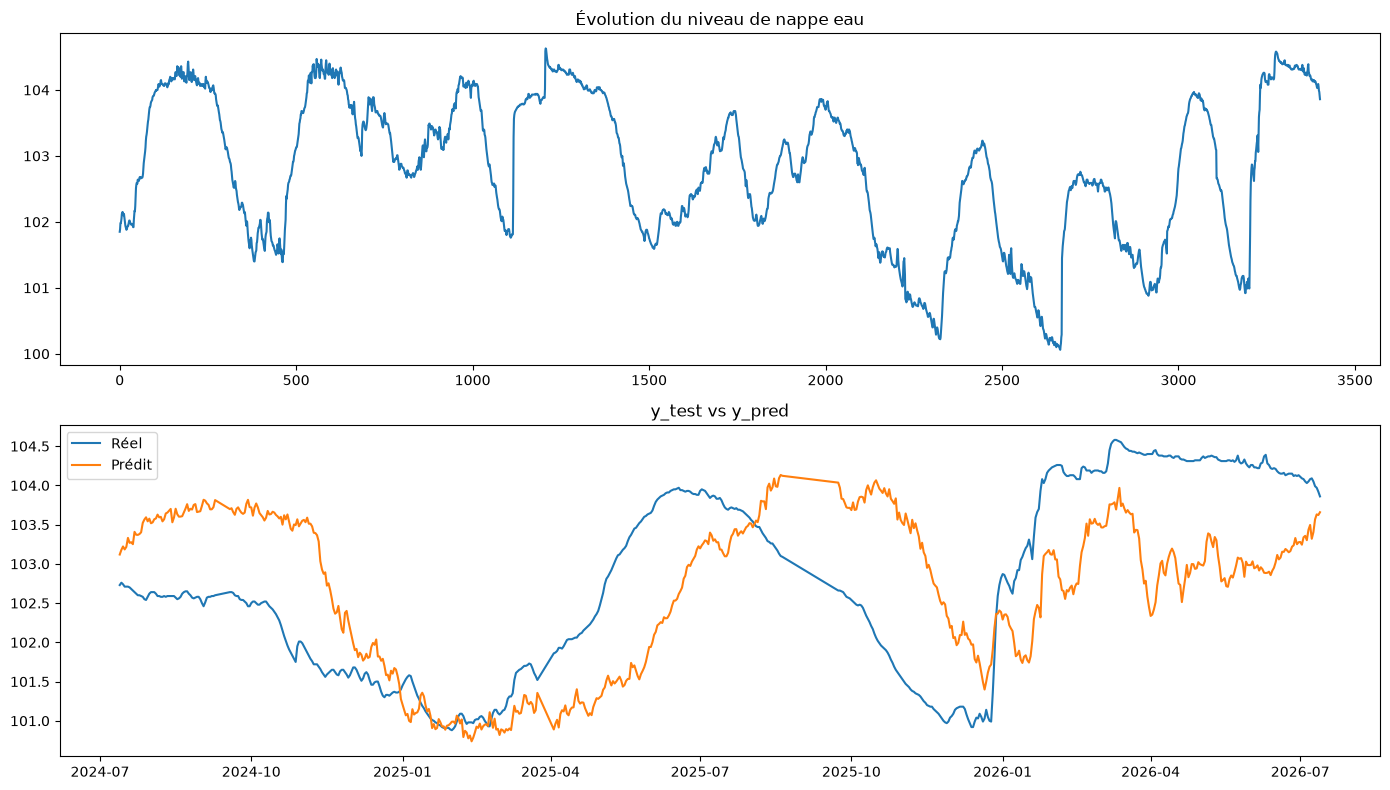

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série complète
axes[0].plot(df.index, df["niveau_nappe_eau"])
axes[0].set_title("Évolution du niveau de nappe eau")

# Prédictions vs réel
axes[1].plot(y_test.index, y_test, label="Réel")
axes[1].plot(y_test.index, y_pred, label="Prédit")
axes[1].set_title("y_test vs y_pred")
axes[1].legend()

plt.tight_layout()
plt.show()

## XGBoost regressor

In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [22]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4, 
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    Function to run a XGBoost Regressor on a train and test set.
    Return the prediction and evaluation metrics (R2 on train and test, RMSE, MAE)
    """
    model = XGBRegressor(
        n_estimators        = n_estimators,
        learning_rate       = learning_rate,
        max_depth           = max_depth,
        subsample           = subsample,
        colsample_bytree    = colsample_bytree,
        random_state        = random_state,
        )
    
    X_train, X_test, y_train, y_test = preprocessing(df)
    
    # Training of the model
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    evaluation_metrics_xgboost_reg = {
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE': rmse,
        'MAE': mae}
    
    return y_pred, evaluation_metrics_xgboost_reg

In [23]:
y_pred, evaluation_metrics_xgboost_reg = xgboost_regressor(df)

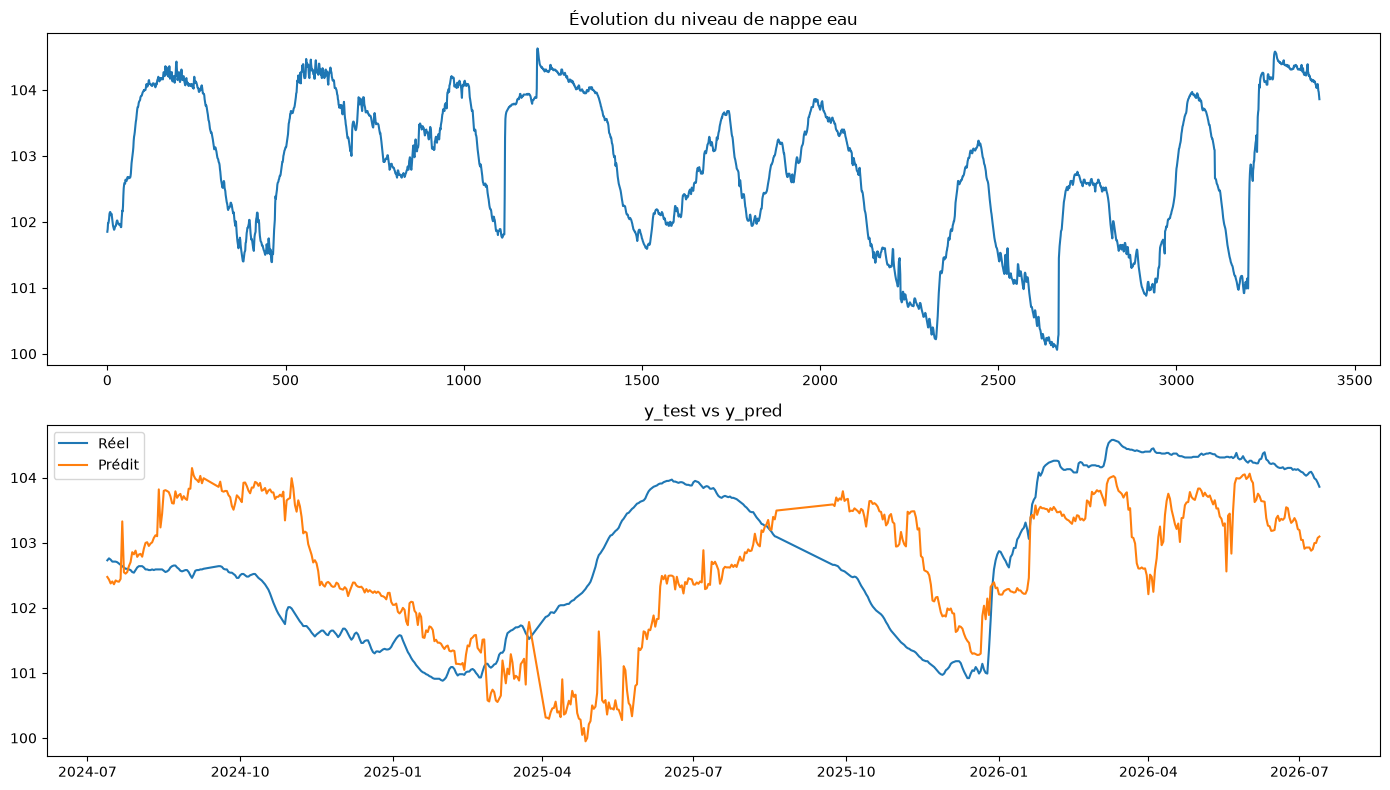

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série complète
axes[0].plot(df.index, df["niveau_nappe_eau"])
axes[0].set_title("Évolution du niveau de nappe eau")

# Prédictions vs réel
axes[1].plot(y_test.index, y_test, label="Réel")
axes[1].plot(y_test.index, y_pred, label="Prédit")
axes[1].set_title("y_test vs y_pred")
axes[1].legend()

plt.tight_layout()
plt.show()